# Wedding cake rough draft — alignment and reconstruction of measured data

Rough working notebook: the same sequence as `tomoMono_demo.ipynb`, but run on real measured
phase projections instead of a simulated phantom. There is no ground truth here, so alignment
is judged by the reconstruction and by the consistency metrics at the end. It currently points
at the Co-doped phase stack in `data/`.

1. **Load** the projection stack, crop it to a workable field of view, and load the matching tilt angles.
2. **Reconstruct before aligning** to see the starting point.
3. **Align** with projection matching, restricted to an ROI around the sample.
4. **Reconstruct after aligning** (optionally save the volume as a TIFF).
5. **Score** the alignment with RCS and sinogram consistency.

Several cells keep commented-out parameter variants from tuning runs — those are alternatives,
not steps that need to be re-enabled.

## Import libraries

In [1]:
import numpy as np
import tomopy
from helperFunctions import MoviePlotter, convert_to_numpy, degree_to_positiveRadians
from tomoDataClass import tomoData

[gpu] active backends: numpy, svmbir


## Load Co-doped Data

Instead of a simulated Shepp3D phantom, this notebook uses the real Co-doped phase projections saved in the `tomoMono` folder:

- `Co_doped_phase_stack.tiff` — the 3D projection stack (angle, y, x)
- `Co_doped_angles.npy` — the tilt angle (degrees) for each slice, index-matched to the stack
- `Co_doped_slice_order.csv` — human-readable record of `slice_index, scan, angle_deg`

Because this is measured experimental data, it already contains real misalignment and noise, so the phantom-only `jitter()` / `add_noise()` steps are dropped.

In [ ]:
# File paths for the saved Co-doped data
PHASE_STACK = 'data/Co_doped_phase_stack.tiff'
ANGLES_FILE = 'data/Co_doped_angles.npy'
SLICE_ORDER = 'data/Co_doped_slice_order.csv'

algorithm = 'gridrec'

In [3]:
# Load the phase projection stack (angle, y, x)
projections, scale_info = convert_to_numpy(PHASE_STACK)
projections = projections.astype(np.float32)
downsample = 1
projections = projections[:, 60:-262:downsample, 75:-87:downsample] #Crop to be good size 1000,600 at full res2
print(projections.shape)
print("Measured Co-doped phase projections")
MoviePlotter(projections)  # Plots each projection

(166, 800, 600)
Measured Co-doped phase projections


Output()

In [4]:
# Load the per-slice tilt angles (saved in degrees) and convert to positive radians
angles_deg = np.load(ANGLES_FILE)
angles = degree_to_positiveRadians(angles_deg)
angles = (angles + np.pi) % (2 * np.pi)
print(f"{len(angles)} angles, spanning {angles_deg.min()} to {angles_deg.max()} degrees")
assert len(angles) == projections.shape[0], "angle count must match number of projections"
# print(angles)

166 angles, spanning -90.0 to 90.0 degrees


In [5]:
# croppedProjections = projections[::, 60:-60:4, 75:-75:4]
tomo = tomoData(projections, angles)
print("Measured projections (real misalignment + noise already present)")
tomo.makeNotebookProjMovie()

Measured projections (real misalignment + noise already present)


Output()

## Align Data

In [ ]:
# Baseline: reconstruct the unaligned projections. Blurring and streaks here are the
# misalignment we are about to correct, not a failure of the reconstruction algorithm.
tomo.reconstruct(algorithm=algorithm)
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()

tomo.makeNotebookReconMovie()

# print(tomo.ang)



Using CPU-based reconstruction. Algorithm:  gridrec
Reconstruction completed.

Bad reconstruction prior to alignment


Output()



Sinogram consistency:
  x_cm (horizontal) — RMSE: 1.9013 px  |  R²: 0.265359
  y_cm (vertical)   — RMSE: 4.5965 px  |  R²: 0.000000
  Combined RMSE:       3.5173 px
Computing reprojections from reconstruction for sinogram comparison...


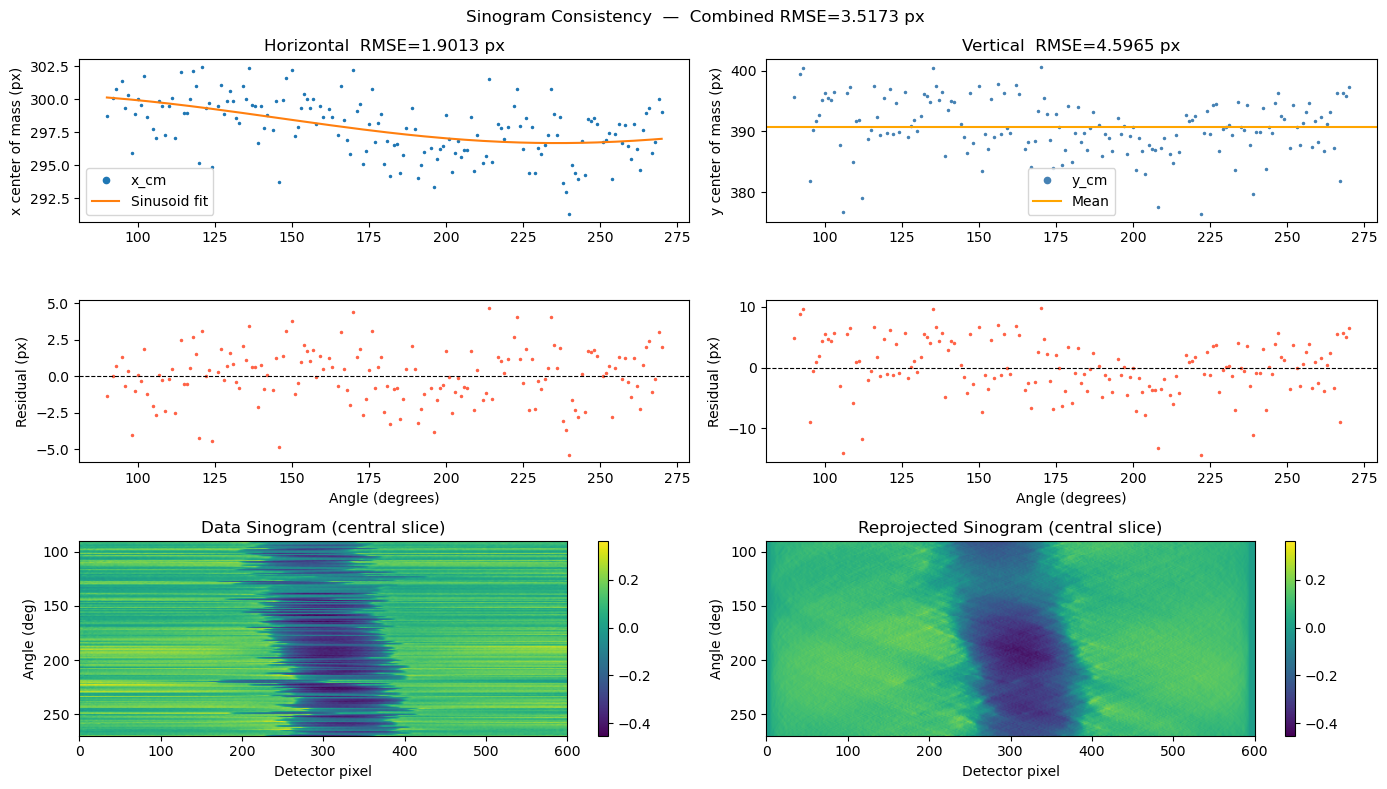

In [7]:
combined_rmse, x_rmse, y_rmse, x_cm, y_cm = tomo.sinogram_consistency_score(plot=True)



Normalizing projections


Cross-Correlation Alignment  [4x downsample | ROI y=[0, 800] x=[0, 600] | intensity mode]


Iteration 1/5: 100%|██████████| 165/165 [00:05<00:00, 28.09it/s]


  Projection 83 shift: y=14.8800 px, x=0.4800 px


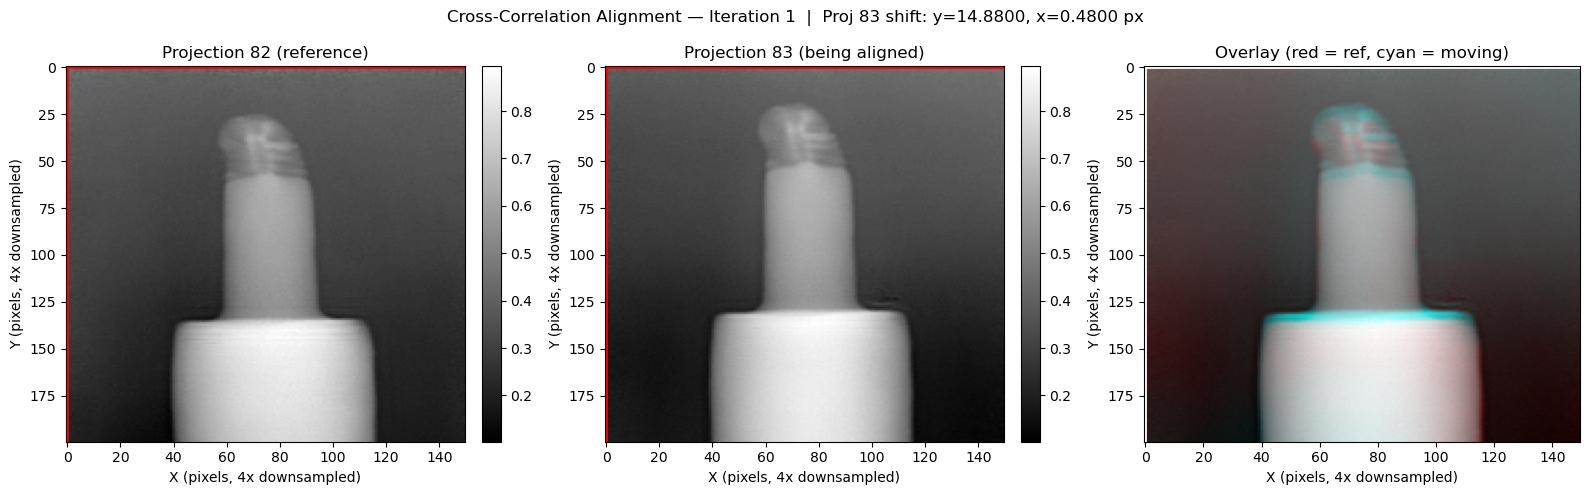

Iteration 1: avg shift = 20.3089 px, max shift = 83.9939 px


Iteration 2/5: 100%|██████████| 165/165 [00:05<00:00, 28.20it/s]


Iteration 2: avg shift = 3.1431 px, max shift = 17.7477 px


Iteration 3/5: 100%|██████████| 165/165 [00:05<00:00, 28.32it/s]


Iteration 3: avg shift = 1.3048 px, max shift = 8.9657 px


...

Iteration 4: avg shift = 0.7627 px, max shift = 3.5236 px


Iteration 5/5: 100%|██████████| 165/165 [00:05<00:00, 28.23it/s]


Iteration 5: avg shift = 0.6324 px, max shift = 7.6416 px
Maximum iterations reached without convergence.
Centering Projections
Original center: 297.5
Center of frame: 300
Aligned projections shifted by 2.5 pixels
Projections are currently centered at pixel 300.25. Residual offset: 0.25


Cross-Correlation Alignment  [2x downsample | ROI y=[0, 300] x=[140, 460] | intensity mode]


Iteration 1/5: 100%|██████████| 165/165 [00:01<00:00, 90.38it/s]


  Projection 83 shift: y=0.1600 px, x=-0.1600 px


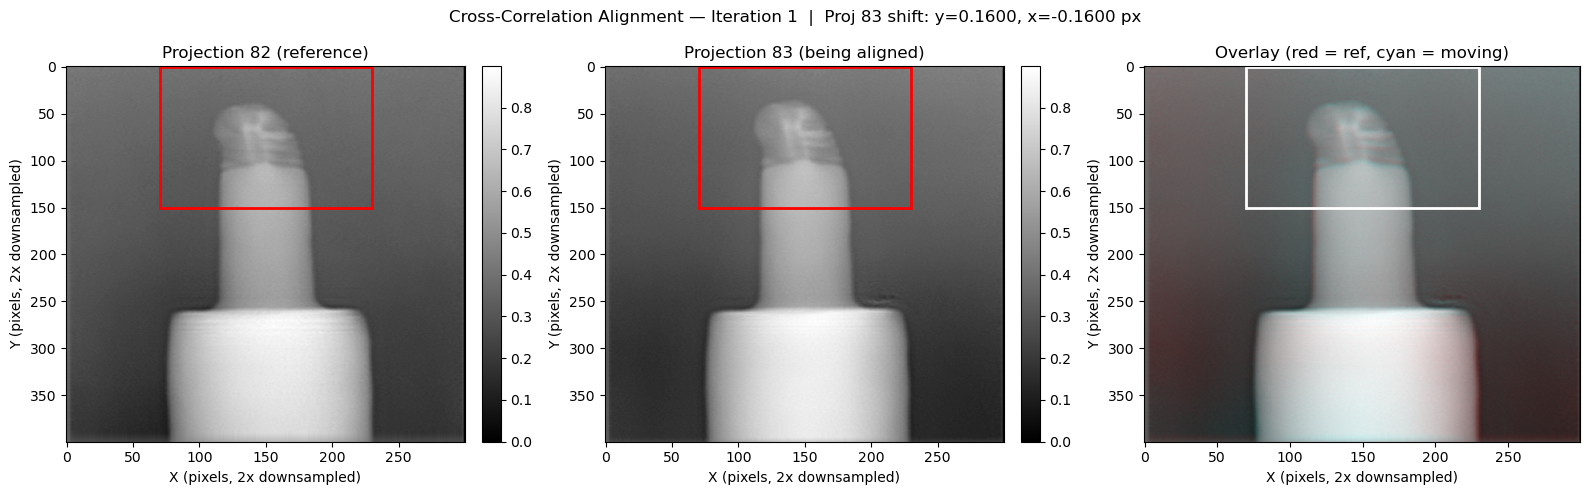

Iteration 1: avg shift = 0.2606 px, max shift = 4.0800 px


Iteration 2/5: 100%|██████████| 165/165 [00:01<00:00, 90.97it/s]


Iteration 2: avg shift = 0.3245 px, max shift = 13.2802 px


Iteration 3/5: 100%|██████████| 165/165 [00:01<00:00, 91.08it/s]


Iteration 3: avg shift = 0.2220 px, max shift = 3.4484 px


...

Iteration 4: avg shift = 0.1824 px, max shift = 0.8040 px


Iteration 5/5: 100%|██████████| 165/165 [00:01<00:00, 91.17it/s]


Iteration 5: avg shift = 0.1608 px, max shift = 0.8944 px
Maximum iterations reached without convergence.


Cross-Correlation Alignment  [full resolution | ROI y=[0, 300] x=[140, 460] | intensity mode]


Iteration 1/5: 100%|██████████| 165/165 [00:01<00:00, 161.73it/s]


  Projection 83 shift: y=0.0400 px, x=0.2400 px


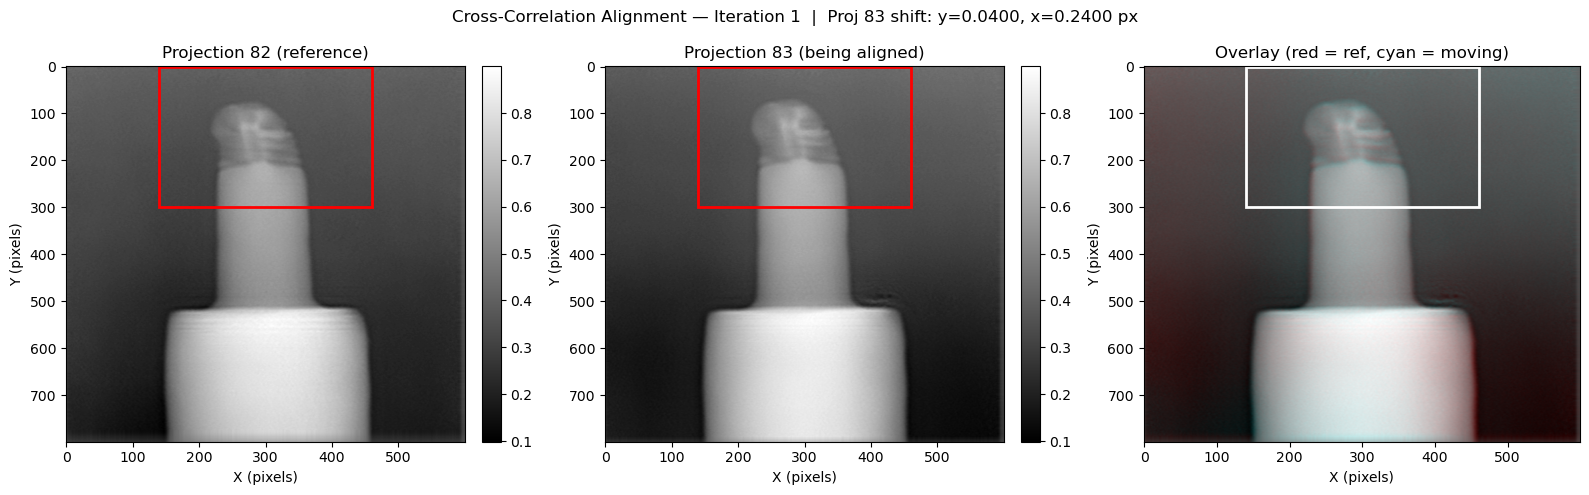

Iteration 1: avg shift = 0.7300 px, max shift = 4.8407 px


Iteration 2/5: 100%|██████████| 165/165 [00:01<00:00, 162.53it/s]


Iteration 2: avg shift = 0.4948 px, max shift = 3.2802 px


Iteration 3/5: 100%|██████████| 165/165 [00:01<00:00, 162.45it/s]


Iteration 3: avg shift = 0.4067 px, max shift = 2.4030 px


Iteration 4/5: 100%|██████████| 165/165 [00:01<00:00, 163.05it/s]


Iteration 4: avg shift = 0.4275 px, max shift = 3.2800 px


Iteration 5/5: 100%|██████████| 165/165 [00:01<00:00, 162.68it/s]


Iteration 5: avg shift = 0.4864 px, max shift = 4.0000 px
Maximum iterations reached without convergence.
Centering Projections
Original center: 292.5
Center of frame: 300
Aligned projections shifted by 7.5 pixels
Projections are currently centered at pixel 300.0. Residual offset: 0.0


Apply shifts to final projections: 100%|██████████| 166/166 [00:16<00:00, 10.10it/s]


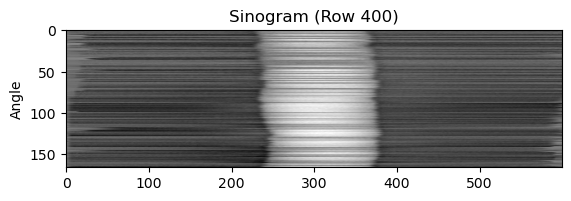

Output()

Output()

In [8]:
# tomo.reset_workingProjections() #You can pass x_size/y_size for tighter cropping
# tomo.normalize(isPhaseData=True)
# tomo.cross_correlate_align(tolerance=0.001, max_iterations=20, stepRatio=0.9, yROI_Range=None, xROI_Range=None)
# tomo.projection_matching_alignment(max_iterations=5, tolerance=0.05, algorithm='gridrec', standardize=False)
# tomo.make_updates_shift()

tomo.reset_workingProjections() #You can pass x_size/y_size for tighter cropping
tomo.normalize(isPhaseData=True)
# tomo.center_projections()

tomo.cross_correlate_align(
        tolerance=0, maxShiftTolerance=0, max_iterations=5, stepRatio=0.8,
        downsample=4, use_grad=False,
        yROI_Range=None,
        xROI_Range=None,
        isFull360=False,
        plot=True
    )
tomo.center_projections()
tomo.cross_correlate_align(
        tolerance=0, maxShiftTolerance=0, max_iterations=5, stepRatio=0.8,
        downsample=2, use_grad=False,
        yROI_Range=[0, 300//downsample],
        xROI_Range=[140//downsample,460//downsample],
        # yROI_Range=None,
        # xROI_Range=None,
        isFull360=False,
        plot=True
    )
tomo.cross_correlate_align(
        tolerance=0, maxShiftTolerance=0, max_iterations=5, stepRatio=0.8,
        downsample=1, use_grad=False,
        yROI_Range=[0, 300//downsample],
        xROI_Range=[140//downsample,460//downsample],
        # yROI_Range=None,
        # xROI_Range=None,
        isFull360=False,
        plot=True
    )
tomo.center_projections()

tomo.make_updates_shift()

tomo.displayWorkingSinogram()
MoviePlotter(tomo.workingProjections)  # Plots each projection
tomo.makeNotebookProjMovie()



Projection Matching Alignment (PMA) [optical_flow | gradient mode]
Centering Projections


Original center: 300.0
Center of frame: 300
Projections are currently centered at pixel 300.0. Residual offset: 0.0

--- PMA Level 0 (1x downsampled, 3 iterations) ---
Using ROI: x=[140, 460], y=[0, 300] (downsampled by 1x)
H and W values are 800 and 600
Downsample ROI bounds are x=140 to 460, y=0 to 300
Reconstructing on padded window x=108-492, y=0-332 (margin y=32, x=32 ds-px; ROI at x offset 32, y offset 0); recon_center=192.00


PMA Level 0 iterations:   0%|          | 0/3 [00:00<?, ?it/s]

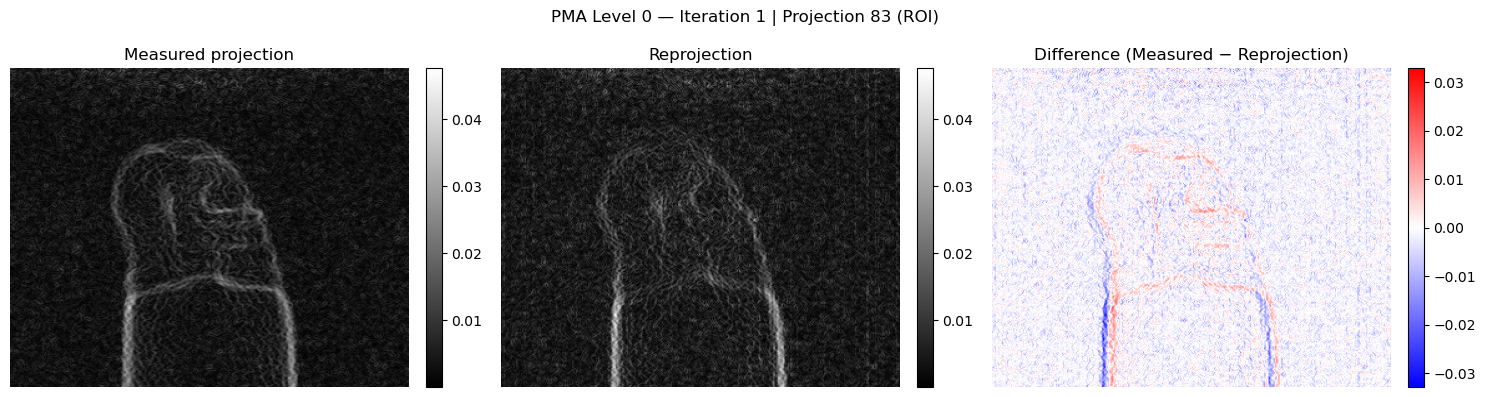

PMA Level 0 iterations:  33%|███▎      | 1/3 [00:15<00:30, 15.11s/it]

Iteration 1: avg shift = 0.0238 px, max shift = 0.0871 px


PMA Level 0 iterations:  67%|██████▋   | 2/3 [00:29<00:14, 14.60s/it]

Iteration 2: avg shift = 0.0238 px, max shift = 0.0872 px


PMA Level 0 iterations: 100%|██████████| 3/3 [00:43<00:00, 14.44s/it]

Iteration 3: avg shift = 0.0239 px, max shift = 0.0873 px



PMA complete.


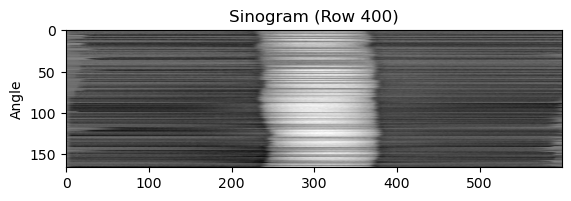

Apply shifts to final projections: 100%|██████████| 166/166 [00:08<00:00, 19.07it/s]


Output()

In [9]:
# tomo.workingProjections = tomo.finalProjections.copy()
# tomo.normalize(isPhaseData=True)

tomo.projection_matching_alignment(
        levels=1, scale=1, iterations_per_level=[3],
        tolerance=0.0, algorithm=algorithm, standardize=False, use_grad=True,
        shift_method='optical_flow', stepRatio=0.8,
        use_highpass_filter=False,
        plot=True,
        yROI_Range=[0, 300//downsample],
        xROI_Range=[140//downsample,460//downsample],
        # xROI_Range=None,
        # yROI_Range=None,
        max_step = 5
    )

# MoviePlotter(tomo.workingProjections)  # Plots each projection
tomo.displayWorkingSinogram()
tomo.make_updates_shift()
tomo.makeNotebookProjMovie()


In [ ]:
tomo.reconstruct(algorithm=algorithm)
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

# Save the reconstruction as a tiff file from helperFunctions.py save_to_tiff 
# def convert_to_tiff(numpy_data, file_location, scale_info=None):
# from helperFunctions import convert_to_tiff
# convert_to_tiff(-tomo.recon, f'Co_doped_reconstruction_{downsample}xds.tiff', scale_info=scale_info)



Using CPU-based reconstruction. Algorithm:  gridrec
Reconstruction completed.

Good Reconstruction after alignment


Output()

## Assess Alignment Quality

Now that alignment and reconstruction are done, we quantify how good the alignment is with two metrics:

- **Reprojection Consistency Score (RCS)** — *the most reliable metric for alignment quality.* It reprojects the reconstructed volume at every angle and compares it against the measured projections (per-angle NRMSE). Lower is better (`< 0.10` is excellent), and the per-angle bar chart flags any projections that are still misaligned.
- **Sinogram Consistency Score** — *a rough gauge, not a reliable score.* It checks the Helgason-Ludwig center-of-mass conditions on the sinogram. Use it to get a coarse sense of how close the alignment is, to spot outlier projections, and to view the central-slice sinogram.

(For *reconstruction* quality / resolution rather than alignment, use `fourier_shell_correlation` — the gold-standard half-dataset FSC metric.)



Reusing cached reprojections from tomo.finalReprojections.
Computing per-angle NRMSE (normalize_method='none')...


NRMSE per angle: 100%|██████████| 166/166 [00:00<00:00, 182.05it/s]



─── Reprojection Consistency Score ───────────────────────
  normalize_method:   'none'
  RCS (mean NRMSE):   0.6600
  Best  angle [  82]:  NRMSE = 0.2030
  Worst angle [  40]:  NRMSE = 3.2652
  Std across angles:  0.5054
  Verdict:  ✗  Poor — significant misalignment or reconstruction failure.
───────────────────────────────────────────────────────────



/home/ljh79/TomoMono/metrics/reprojection_consistency.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


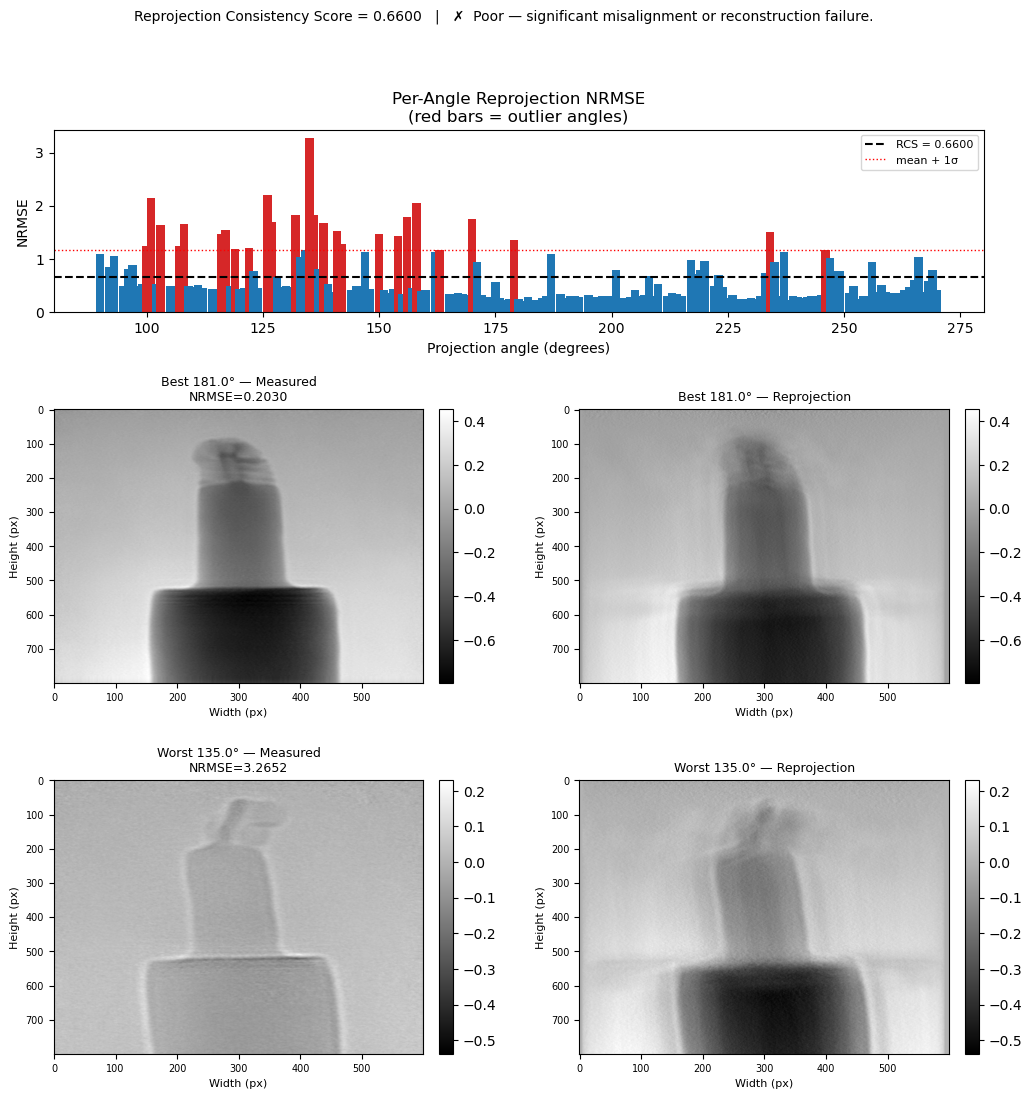

In [11]:
# Reprojection Consistency Score — best metric of alignment quality (lower is better)
rcs, per_angle_nrmse, _ = tomo.reprojection_consistency_score(plot=True)



Sinogram consistency:
  x_cm (horizontal) — RMSE: 3.4749 px  |  R²: 0.010908
  y_cm (vertical)   — RMSE: 8.8756 px  |  R²: 0.000000
  Combined RMSE:       6.7398 px


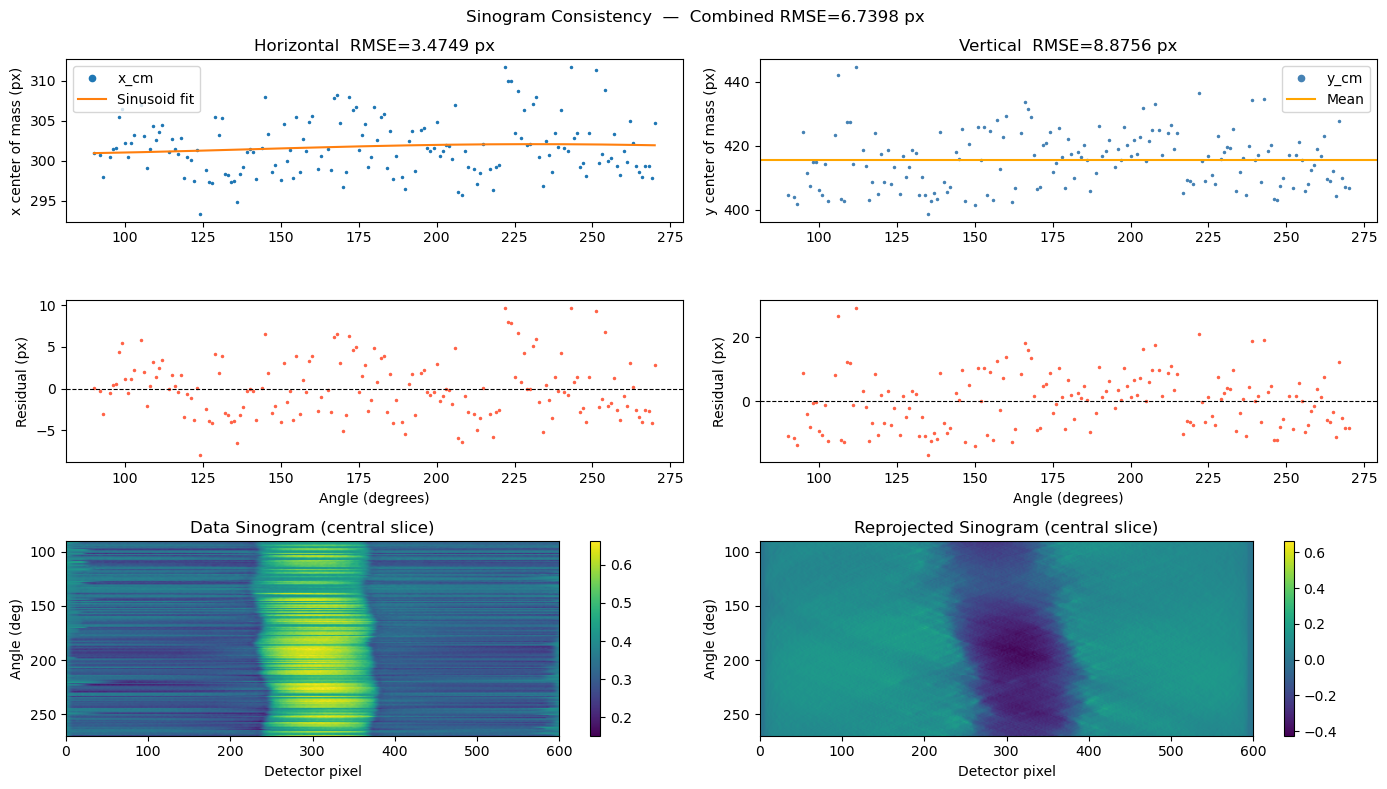

In [12]:
# Sinogram Consistency Score — rough gauge of alignment + central-slice sinogram view
combined_rmse, x_rmse, y_rmse, x_cm, y_cm = tomo.sinogram_consistency_score(plot=True)